In [1]:
import os
import torch
import pandas as pd
import scanpy as sc
from SPHERE.preprocess import *
from SPHERE.SPHERE import *
from SPHERE.utils import *
import numpy as np
device = torch.device('cuda:2' if torch.cuda.is_available() else 'cpu')
random_seed = 2022
fix_seed(random_seed)

## Cerebellum

In [ ]:
datasets = ['./bin_super_hc4um.h5ad',
            './bin_super.h5ad',]

adata_list = [sc.read_h5ad(dataset) if isinstance(dataset, str) else dataset for dataset in datasets]
slice_name_list = ['4um', '8um']

import anndata as ad
adata = ad.concat(adata_list, label="slice_name", keys=slice_name_list)
print(adata)

AnnData object with n_obs × n_vars = 2464809 × 8626
    obs: 'slice_name'
    var: 'n_cells'
    uns: 'adj_spatial_sparse', 'neighbors', 'umap'
    obsm: 'X_lsi', 'X_umap', 'adj_combined', 'adj_feature', 'feat', 'latent', 'spatial'
    obsp: 'connectivities', 'distances'


/home/yuzhuohan/miniconda3/envs/SPHERE/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [ ]:
adata.X[adata.X.nonzero()] = 1
sc.pp.filter_genes(adata, min_cells=int(0.03 * adata.shape[0]))
X = adata.X
X_norm = sklearn.preprocessing.Normalizer(norm="l1").fit_transform(X)
X_norm = np.log1p(X_norm * 1e4)
from sklearn.decomposition import PCA
pca1 = PCA(n_components=100)    
input_matrix = pca1.fit_transform(X_norm.toarray())
adata.obsm['X_pca'] = input_matrix
adata.obsm['feat'] = adata.obsm['X_pca'].copy()


In [ ]:
adata = construct_neighbor_graph_inte_scale(adata, slice_name_list,loc_neighbors=6,gene_neighbors=5)

In [3]:
batch_categories = np.unique(adata.obs['slice_name'])
batch_to_index = {batch: idx for idx, batch in enumerate(batch_categories)}
batch_indices = adata.obs['slice_name'].map(batch_to_index).values
num_batches = len(batch_categories)
batch_labels = np.eye(num_batches)[batch_indices]

In [6]:
model = SPHERE(adata, device=device, learning_rate=0.001, epochs=10, dim_hid=64, dim_input=100,
               integrate=True, batch_label=batch_labels,slice_name_list = slice_name_list, lambda_fea_recon=0.8,lambda_spa_recon=1.5,
               lambda_recon=4,lambda_con=5,lambda_align=8,lambda_latent=20,scale=True,pretrain=False)


/home/yuzhuohan/miniconda3/envs/SPHERE/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [ ]:
output = model.train_inte_scale(batch_size=2048)
adata.obsm['latent'] = output['latent']
adata.obsm['latent'] = pca(adata, use_reps='latent', n_comps=20)
# sc.pp.neighbors(adata, use_rep='latent', n_neighbors=30)


Epoch 10/10: 100%|██████████| 1203/1203 [02:17<00:00,  8.72it/s, loss=12.2937]


In [ ]:
from sklearn.mixture import GaussianMixture
import scanpy as sc
import pandas as pd
gm = GaussianMixture(n_components=6, covariance_type='tied', random_state=1234)
y = gm.fit_predict(adata.obsm['latent'], y=None)
adata.obs["leiden"] = pd.Series(y, index=adata.obs.index, dtype='category')

/home/yuzhuohan/miniconda3/envs/SPHERE/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Text(0, 0.5, '')

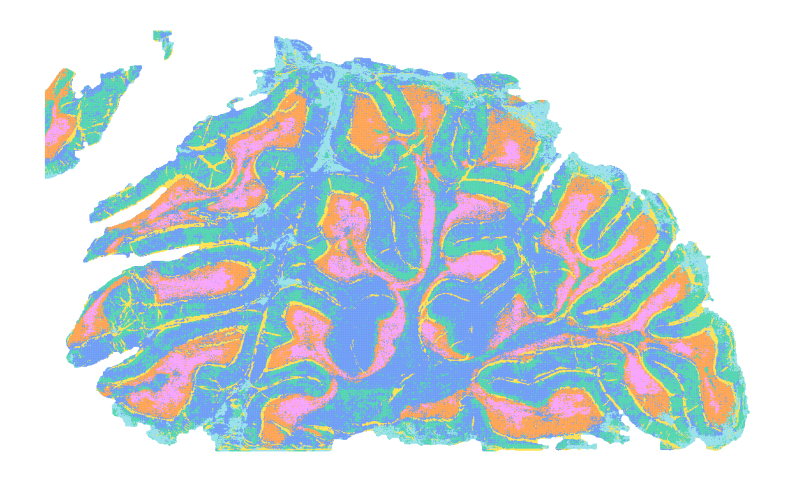

In [ ]:
adata_sub = adata[adata.obs['slice_name']=="8um"]
adata_sub.obsm['spatial'][:, 1] = -1*adata_sub.obsm['spatial'][:, 1]

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 6)
plot_color=["#2A6FF5","#F67AFF","#68D6E3","#FFD600","#FF7A00","#00C48C"]
fig, ax = plt.subplots()
sc.pl.embedding(adata_sub, basis="spatial",
                color="leiden",
                s=1,
                show=False, frameon=False,
                palette=plot_color,ax=ax,legend_loc=None)

ax.set_title("")  
ax.set_xlabel("")  
ax.set_ylabel("")

/tmp/ipykernel_2374046/4116418905.py:2: ImplicitModificationWarning: Trying to modify attribute `.obsm` of view, initializing view as actual.
  adata_sub.obsm['spatial'][:, 1] = -1*adata_sub.obsm['spatial'][:, 1]
/home/yuzhuohan/miniconda3/envs/SPHERE/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Text(0, 0.5, '')

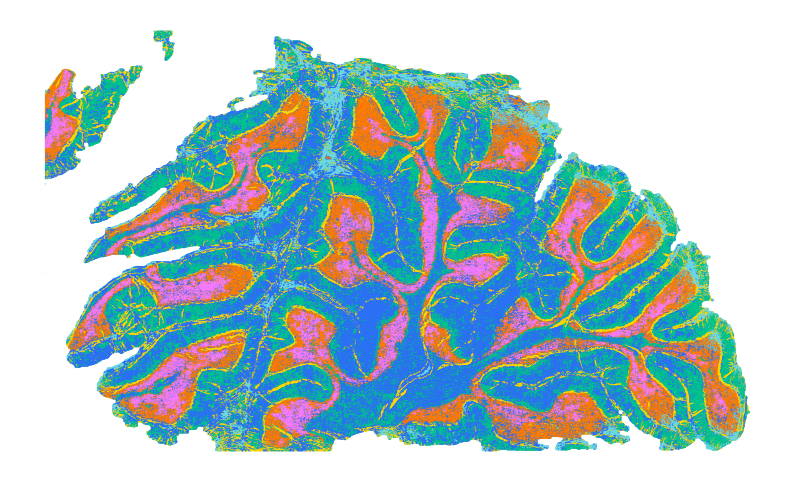

In [11]:
adata_sub = adata[adata.obs['slice_name']=="4um"]
adata_sub.obsm['spatial'][:, 1] = -1*adata_sub.obsm['spatial'][:, 1]

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 6)
plot_color=["#2A6FF5","#F67AFF","#68D6E3","#FFD600","#FF7A00","#00C48C"]
fig, ax = plt.subplots()
sc.pl.embedding(adata_sub, basis="spatial",
                color="leiden",
                s=1,
                show=False, frameon=False,
                palette=plot_color,ax=ax,legend_loc=None)

ax.set_title("")  
ax.set_xlabel("")  
ax.set_ylabel("")